# Khám phá dữ liệu (EDA) & Visualize Features
Notebook này giúp bạn hình dung dữ liệu chứng khoán (VD: FPT) sau khi đã chạy qua bước Feature Engineering.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Đọc dữ liệu FPT từ thư mục interim
data_path = '../data/interim/FPT.VN_features.csv'
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(f"Dữ liệu có {df.shape[0]} dòng và {df.shape[1]} cột.")
df.tail()

Dữ liệu có 1774 dòng và 11 cột.


,Close,High,Low,Open,Volume,SMA_10,SMA_50,MACD,RSI_14,BB_High,BB_Low
Date,,,,,,,,,,,
2024-12-25,115372.914062,115678.948247,115066.887439,115219.900751,3179071,114370.667969,106667.760000,2535.803697,67.091074,117964.174965,107910.738316
2024-12-26,114607.835938,115831.957510,114072.285585,115525.923336,2825124,114340.064844,106878.145781,2412.041122,63.214133,117270.748937,109473.749500
2024-12-27,114454.820312,114684.344048,113766.256668,114378.317441,3240550,114347.714063,107085.471250,2275.382119,62.437026,117135.572442,110090.920527
2024-12-30,115143.390625,115372.914374,113613.249943,114301.813628,2507736,114393.618750,107329.361250,2197.311505,64.549019,116728.145450,111133.357675
2024-12-31,116673.539062,117744.639810,114990.377505,115296.411691,4558048,114737.902344,107640.323281,2233.167605,68.753427,116902.133337,111533.173695


### 1. Biểu đồ Giá kèm Trend & Volatility (Bollinger Bands, SMA)

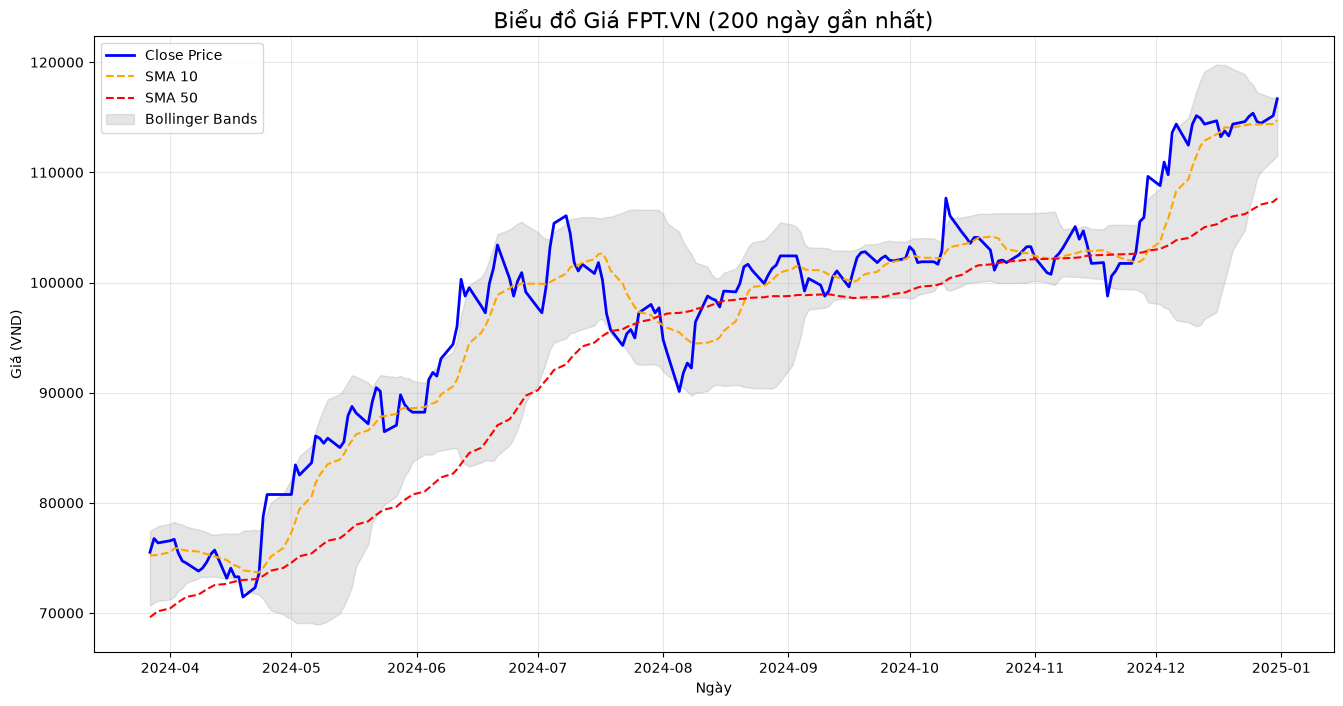

In [2]:
plt.figure(figsize=(16, 8))

# Chỉ lấy 200 ngày gần nhất để biểu đồ không bị rối
recent_df = df.iloc[-200:]

# Vẽ giá Close
plt.plot(recent_df.index, recent_df['Close'], label='Close Price', color='blue', linewidth=2)

# Vẽ đường SMA
plt.plot(recent_df.index, recent_df['SMA_10'], label='SMA 10', color='orange', linestyle='--')
plt.plot(recent_df.index, recent_df['SMA_50'], label='SMA 50', color='red', linestyle='--')

# Vẽ dải Bollinger Bands
plt.fill_between(recent_df.index, recent_df['BB_High'], recent_df['BB_Low'], color='gray', alpha=0.2, label='Bollinger Bands')

plt.title('Biểu đồ Giá FPT.VN (200 ngày gần nhất)', fontsize=16)
plt.xlabel('Ngày')
plt.ylabel('Giá (VND)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 2. Heatmap Tương quan (Correlation) giữa các Features
Xem độ tương quan giữa giá và các chỉ báo kỹ thuật.

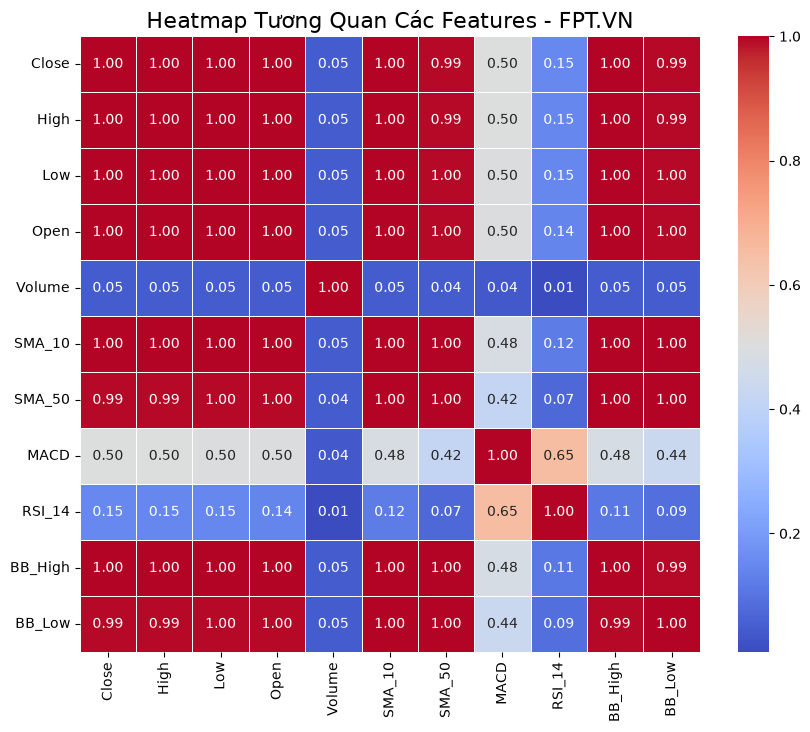

In [3]:
plt.figure(figsize=(10, 8))

# Tính ma trận tương quan
corr = df.corr()

# Vẽ heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Tương Quan Các Features - FPT.VN', fontsize=16)
plt.show()